## Streaming

Methods: `stream()` and `astream()`
- These methods are sync and async methods for streaming back results

Additional parameters in streaming modes for graph state
- values: This streams the full state of the graph after each node is called.
- updates: This streams updates the state of the graph after each node is called

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from dataclasses import dataclass
from langgraph.graph.message import add_messages
from typing import Annotated
from langchain_core.messages import AnyMessage

@dataclass
class State:
    messages: Annotated[list[AnyMessage], add_messages]

In [3]:
# os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Streaming in Langchain"

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model= os.getenv('GROQ_MODEL'), api_key= os.getenv('GROQ_API_KEY'))
llm.invoke("Hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We just respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 72, 'total_tokens': 102, 'completion_time': 0.070144853, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.013900348, 'prompt_tokens_details': None, 'queue_time': 0.137553191, 'total_time': 0.084045201}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df6f0-d6f6-7673-9d90-8f01413ad7ee-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 30, 'total_tokens': 102, 'output_token_details': {'reasoning': 12}})

### `stream()` Methods 

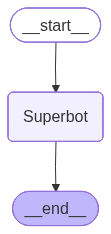

In [10]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

memory = MemorySaver()
def superbot(state:State):
    return {"messages": [llm.invoke(state.messages)]}

builder = StateGraph(State)

builder.add_node("Superbot", superbot)

builder.add_edge(START, "Superbot")
builder.add_edge("Superbot", END)

graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
## Invocation
config = {"configurable": {"thread_id" : 1}}
# graph.invoke({"messages": "Hi, my name is Navneet and I like Football"}, config=config)

In [12]:
for chunk in graph.stream({"messages": "Hi my name is Navneet and i like football"}, config=config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Hey Navneet! Great to meet you. ⚽️  \nWhat’s your favorite football team or league? Do you play the game yourself, or are you more of a fan watching the matches? Let me know—I’m happy to chat about anything football‑related!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hi my name is Navneet and i like football". Probably respond friendly, ask about favorite team, etc. No policy violation. Should be concise.'}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 81, 'total_tokens': 187, 'completion_time': 0.221481345, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003506514, 'prompt_tokens_details': None, 'queue_time': 0.052893756, 'total_time': 0.224987859}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df

In [13]:
config = {"configurable" : {"thread_id" : 1}}
for chunk in graph.stream({"messages": "Hi my name is Navneet and i like football"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Navneet and i like football', additional_kwargs={}, response_metadata={}, id='cf07062d-6d95-4204-9bdf-13d55c292853'), AIMessage(content='Hey Navneet! Great to meet you. ⚽️  \nWhat’s your favorite football team or league? Do you play the game yourself, or are you more of a fan watching the matches? Let me know—I’m happy to chat about anything football‑related!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hi my name is Navneet and i like football". Probably respond friendly, ask about favorite team, etc. No policy violation. Should be concise.'}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 81, 'total_tokens': 187, 'completion_time': 0.221481345, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003506514, 'prompt_tokens_details': None, 'queue_time': 0.052893756, 'total_time': 0.224987859}, 'model_name': 'openai/gpt-oss-120b', 'system_finger

In [15]:
for chunk in graph.stream({"messages": "I also like cricket"}, config=config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Great, you’ve got a double‑sport passion! 🎉  \n\n### Football side\n- **Team/League:** Which club or national side gets your cheers? (e.g., Manchester United, Barcelona, the Premier League, La\u202fLiga, etc.)  \n- **Memorable moment:** Any game that still gives you goosebumps? A dramatic comeback, a stunning free‑kick, a World Cup final…  \n\n### Cricket side\n- **Format:** Do you gravitate toward Tests, ODIs, T20s, or a mix?  \n- **Team/League:** Are you an India fan, an Aussie supporter, a West Indies lover, or perhaps a franchise‑league follower (IPL, BBL, CPL, The Hundred)?  \n- **Player:** Any batsman or bowler you admire? (Virat\u202fKohli, Jasprit\u202fBumrah, Babar\u202fAzam, Rashid\u202fKhan, etc.)  \n\n### A quick fun fact for each sport  \n- **Football:** The fastest goal ever recorded in a professional match was scored by **Nawaf Al‑Abed** after just **2.4\u202fseconds** in a Saudi Arabian league game (2014).  \n- **Cricket:** 

In [ ]:
for chunk in graph.stream({"messages": "I love sport"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Navneet and i like football', additional_kwargs={}, response_metadata={}, id='cf07062d-6d95-4204-9bdf-13d55c292853'), AIMessage(content='Hey Navneet! Great to meet you. ⚽️  \nWhat’s your favorite football team or league? Do you play the game yourself, or are you more of a fan watching the matches? Let me know—I’m happy to chat about anything football‑related!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hi my name is Navneet and i like football". Probably respond friendly, ask about favorite team, etc. No policy violation. Should be concise.'}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 81, 'total_tokens': 187, 'completion_time': 0.221481345, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.003506514, 'prompt_tokens_details': None, 'queue_time': 0.052893756, 'total_time': 0.224987859}, 'model_name': 'openai/gpt-oss-120b', 'system_finger

In [17]:
## Creating a New Thread
config = {"configurable" : {"thread_id" : 2}}
for chunk in graph.stream({"messages": "My name is Priyansh and I like Cricket"}, config=config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="Nice to meet you, Priyansh! Cricket is such an exciting sport with so many formats and stories. Do you have a favorite team, player, or a particular match that you’ve enjoyed the most? I'd love to hear more about what draws you to the game!", additional_kwargs={'reasoning_content': 'The user says: "My name is Priyansh and I like Cricket". Likely they are just stating. We can respond politely, maybe ask about their favorite team or player. No disallowed content. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 81, 'total_tokens': 191, 'completion_time': 0.23124583, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.003602222, 'prompt_tokens_details': None, 'queue_time': 0.050716475, 'total_time': 0.234848052}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45f51928b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'g

In [18]:
for chunk in graph.stream({"messages": "I also like football"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='My name is Priyansh and I like Cricket', additional_kwargs={}, response_metadata={}, id='472edee7-acad-474e-9673-7c617c6692e3'), AIMessage(content="Nice to meet you, Priyansh! Cricket is such an exciting sport with so many formats and stories. Do you have a favorite team, player, or a particular match that you’ve enjoyed the most? I'd love to hear more about what draws you to the game!", additional_kwargs={'reasoning_content': 'The user says: "My name is Priyansh and I like Cricket". Likely they are just stating. We can respond politely, maybe ask about their favorite team or player. No disallowed content. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 81, 'total_tokens': 191, 'completion_time': 0.23124583, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.003602222, 'prompt_tokens_details': None, 'queue_time': 0.050716475, 'total_time': 0.234848052}, 'model_name': 'openai/gpt-oss-

In [19]:
for chunk in graph.stream({"messages": "I also like football"}, config=config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Great! Football (soccer) has a massive global following—there’s always something exciting happening, whether it’s a league battle, a cup run, or an international tournament.\n\n#### A few quick conversation starters:\n\n| Topic | Why it’s fun |\n|-------|--------------|\n| **Favorite club** | Talk about your team’s style of play, recent results, or legendary moments. |\n| **Dream match‑up** | Imagine a clash between two historic clubs or national sides—who would you pick? |\n| **Top players** | Compare the skill sets of a classic great (e.g., Maradona, Zidane) with a modern star (e.g., Messi, Mbappé). |\n| **Tactics** | Discuss formations like 4‑3‑3 vs. 3‑5‑2, pressing strategies, or set‑piece routines. |\n| **Football culture** | Chants, rivalries, fan traditions—what makes the atmosphere special for you? |\n\n#### Some quick questions to keep the ball rolling:\n\n1. **Which club do you support, and what drew you to them?**  \n2. **Do you 

### `astream()` Methods

**Streaming method** -> We often want to stream more than grapg state

We can use the astream() methods, which streams back events as they happen inside model

- event: This is the type of event that is being emitted
- name: This is the name of the event
- data: This is the data associated with the event
- metadata: Contains langGrapgh nodes, the node emitting the event.

In [20]:
config = {"configurable" : {"thread_id":3}}

async for event in graph.astream_events({"messages" : "Hi my name is Devendra and I like Kho-Kho"}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi my name is Devendra and I like Kho-Kho'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019df6fe-4352-7253-b486-369d39ea6416', 'metadata': {'thread_id': 3, 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': State(messages=[HumanMessage(content='Hi my name is Devendra and I like Kho-Kho', additional_kwargs={}, response_metadata={}, id='3729f237-9086-43f0-822c-a0a35bba0d30')])}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019df6fe-435a-7a21-8a06-3c0d79ab5f76', 'metadata': {'thread_id': 3, 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:1a98ca8f-c1a9-0396-5611-1857c9f89455'}, 'parent_ids': ['019df6fe-4352-7253-b486-369d39ea6416']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessag